# Credit Card Fraud Detection
- Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- Models:
    1. Logistic Regression
    2. XG Boost
    3. Decision Tree
    4. Random Forest
    5. KNN
    6. Naive Bayes

## Problem Definition
Goal: build a model that reliably catches fraudulent transactions despite them being extremely rare.

In [1]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

## Data Collection

In [2]:
#Load Dataset
df = pd.read_csv('creditcard.csv')
df['Classes'] = df['Class'].map({0: 'Not Fraud', 1: 'Fraud'})

In [ ]:
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Classes
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,Not Fraud
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,Not Fraud
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,Not Fraud
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,Not Fraud
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,Not Fraud


In [ ]:
df.shape

(284807, 32)

In [23]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

There is Class Imbalance
- 0 - Not Fraud
- 1 - Fraud

In [24]:
#seperating for data analysis
notFraud = df[df.Class == 0]
fraud = df[df.Class == 1]

In [25]:
notFraud.Amount.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [26]:
fraud.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [5]:
print("\nClass distribution:")
print(df['Classes'].value_counts())  #Check class balance

#Check for nulls
print("Total missing values:", df.isnull().sum().sum())

#Check for duplicates
print("\nDuplicate rows:", df.duplicated().sum())

df['Classes'].value_counts(normalize=True) * 100


Class distribution:
Classes
Not Fraud    284315
Fraud           492
Name: count, dtype: int64
Total missing values: 0

Duplicate rows: 1081


Classes
Not Fraud    99.827251
Fraud         0.172749
Name: proportion, dtype: float64

## Preprocessing

In [ ]:
#Drop duplicates
#df = df.drop_duplicates()
#not dropping duplicates cause we are losing some fraud cases

# print("New shape:", df.shape)
# print("\nClass distribution after dropping duplicates:")
# print(df['Classes'].value_counts())
# print(df['Classes'].value_counts(normalize=True) * 100)

New shape: (284807, 32)

Class distribution after dropping duplicates:
Classes
Not Fraud    284315
Fraud           492
Name: count, dtype: int64
Classes
Not Fraud    99.827251
Fraud         0.172749
Name: proportion, dtype: float64


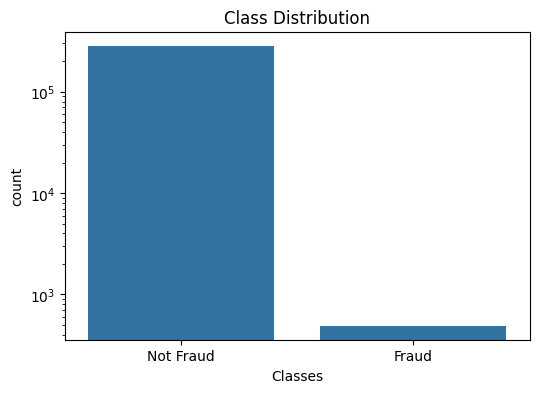

In [6]:
#Class distribution plot
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Classes')
plt.title('Class Distribution')
plt.yscale('log')  #log scale needed- fraud bar would be invisible otherwise
plt.show()

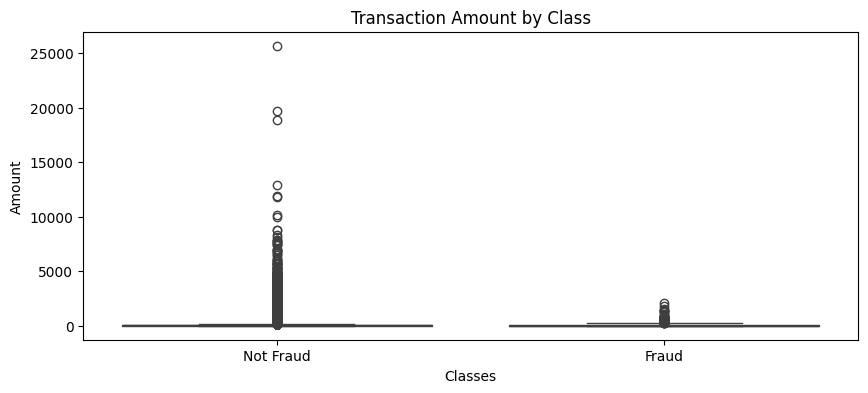

              count        mean         std  min   25%    50%     75%  \
Classes                                                                 
Fraud         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   
Not Fraud  284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05   

                max  
Classes              
Fraud       2125.87  
Not Fraud  25691.16  


In [7]:
#Amount distribution: fraud vs not fraud
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='Classes', y='Amount')
plt.title('Transaction Amount by Class')
plt.show()

print(df.groupby('Classes')['Amount'].describe())

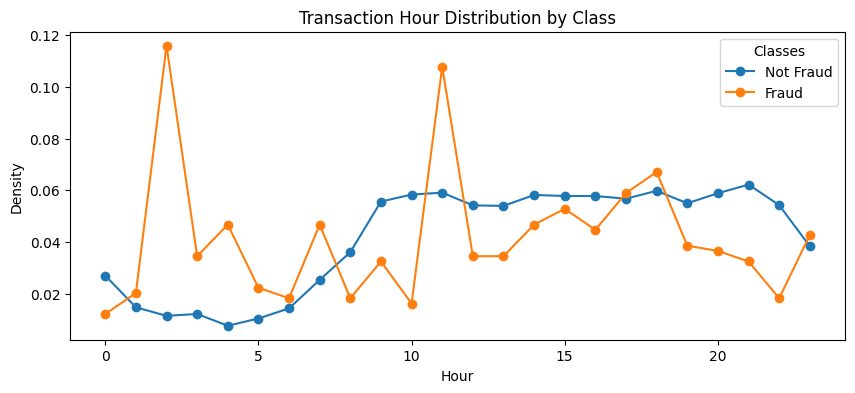

In [8]:
df['Hour'] = (df['Time'] % 86400) // 3600

plt.figure(figsize=(10,4))
for cls in ['Not Fraud', 'Fraud']:
    subset = df[df['Classes'] == cls]
    counts, bins = np.histogram(subset['Hour'], bins=24, range=(0,24), density=True)
    plt.plot(bins[:-1], counts, marker='o', label=cls)
plt.xlabel('Hour')
plt.ylabel('Density')
plt.title('Transaction Hour Distribution by Class')
plt.legend(title='Classes')
plt.show()

In [9]:
fraud_hours = df[df['Classes']=='Fraud']['Hour']
print("Most common fraud hours:", fraud_hours.value_counts().head())

Most common fraud hours: Hour
2.0     57
11.0    53
18.0    33
17.0    29
15.0    26
Name: count, dtype: int64


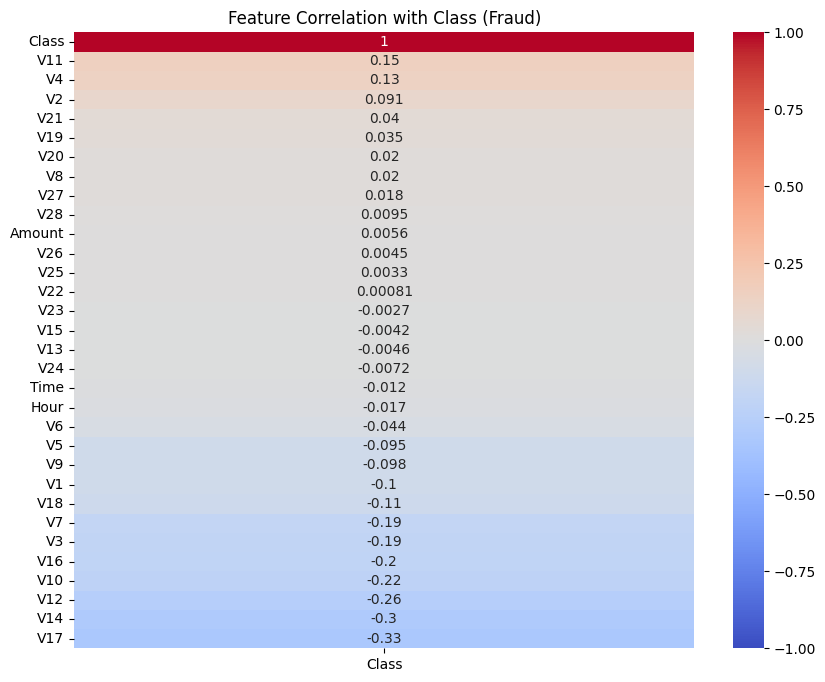

In [10]:
#Correlation with Class
corr = df.drop(columns=['Classes']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr[['Class']].sort_values(by='Class', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation with Class (Fraud)')
plt.show()

### Feature Scaling

In [11]:
#Log-transform Amount first (reduces skew)
df['Amount_log'] = np.log1p(df['Amount'])  #log1p = log(1+x), handles 0 values safely, new column='Amount_log'

#Scale Amount_log and Time
scaler = StandardScaler()
df[['Amount_scaled', 'Time_scaled']] = scaler.fit_transform(df[['Amount_log', 'Time']])

print(df[['Amount', 'Amount_log', 'Amount_scaled', 'Time', 'Time_scaled']].head())

   Amount  Amount_log  Amount_scaled  Time  Time_scaled
0  149.62    5.014760       1.124303   0.0    -1.996583
1    2.69    1.305626      -1.114639   0.0    -1.996583
2  378.66    5.939276       1.682368   1.0    -1.996562
3  123.50    4.824306       1.009339   1.0    -1.996562
4   69.99    4.262539       0.670241   2.0    -1.996541


In [12]:
from sklearn.model_selection import train_test_split

#Features and target
X = df.drop(columns=['Class', 'Classes', 'Amount', 'Amount_log', 'Amount_scaled', 'Time', 'Time_scaled'])
y = df['Class']

#Add back the log-transformed (but not yet scaled) columns
X['Amount_log'] = df['Amount_log']
X['Time'] = df['Time']

#Stratified split (keeps the same fraud/not-fraud ratio in train/test data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

#Fit scaler on training data
scaler = StandardScaler()
X_train[['Amount_scaled', 'Time_scaled']] = scaler.fit_transform(X_train[['Amount_log', 'Time']]) #calculates mean/std from training data only, then applies it to train.s
X_test[['Amount_scaled', 'Time_scaled']] = scaler.transform(X_test[['Amount_log', 'Time']]) #reuses that SAME mean/std, applies it to test data.

X_train = X_train.drop(columns=['Amount_log', 'Time'])
X_test = X_test.drop(columns=['Amount_log', 'Time'])

print("Train shape:", X_train.shape, "Test shape:", y_train.shape)
print("Train fraud ratio:", y_train.value_counts(normalize=True))
print("Test fraud ratio:", y_test.value_counts(normalize=True))

Train shape: (199364, 31) Test shape: (199364,)
Train fraud ratio: Class
0    0.998275
1    0.001725
Name: proportion, dtype: float64
Test fraud ratio: Class
0    0.998268
1    0.001732
Name: proportion, dtype: float64


## Model Training

### Logistic Regression

Using Class weight parameter: https://www.geeksforgeeks.org/machine-learning/how-does-the-classweight-parameter-in-scikit-learn-work/

Accuracy: 0.9985955549313578

Classification Report:
               precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     85295
       Fraud       0.56      0.82      0.67       148

    accuracy                           1.00     85443
   macro avg       0.78      0.91      0.83     85443
weighted avg       1.00      1.00      1.00     85443



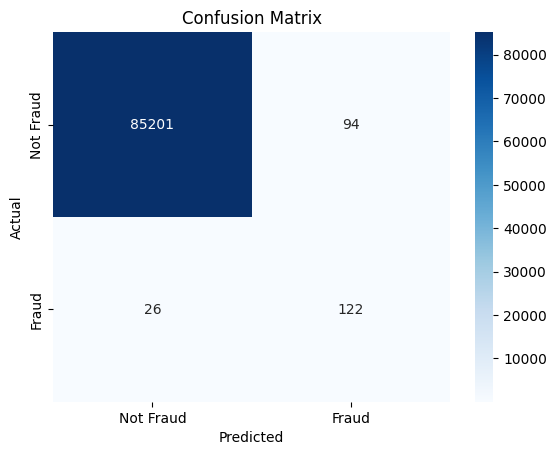

In [13]:
class_weight = {0: 1, 1: 30}  # much gentler than the ~300x 'balanced' would calculate
model = LogisticRegression(solver='lbfgs', max_iter=200, class_weight=class_weight)
model.fit(X_train, y_train)

y_pred_cw2 = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_cw2))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cw2, target_names=['Not Fraud', 'Fraud']))

cm = confusion_matrix(y_test, y_pred_cw2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Logistic Regressing on Undersampled dataset

Undersampled training class distribution:
Class
0    344
1    344
Name: count, dtype: int64

Logistic Regression on Undersampled Data:
Accuracy: 0.9756

              precision    recall  f1-score   support

   Not Fraud       1.00      0.98      0.99     85295
       Fraud       0.06      0.88      0.11       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.55     85443
weighted avg       1.00      0.98      0.99     85443



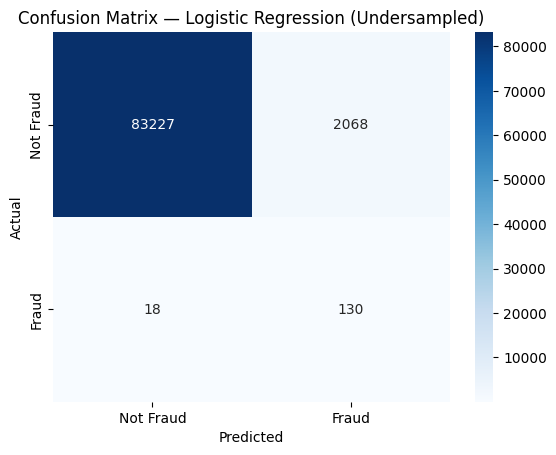

In [37]:
train_data = pd.concat([X_train, y_train], axis=1)

notFraud_train = train_data[train_data['Class'] == 0]
fraud_train = train_data[train_data['Class'] == 1]

notFraud_sample = notFraud_train.sample(n=len(fraud_train), random_state=42)

#Combine into one balanced training set
undersampling_df = pd.concat([notFraud_sample, fraud_train], axis=0)

X_us = undersampling_df.drop(columns='Class')
Y_us = undersampling_df['Class']

print("Undersampled training class distribution:")
print(Y_us.value_counts())

#Train Logistic Regression on the undersampled data
model_us = LogisticRegression(solver='lbfgs', max_iter=200)
model_us.fit(X_us, Y_us)

#IMPORTANT: always evaluate on the real, untouched X_test/y_test — never on undersampled data
y_pred_us = model_us.predict(X_test)

print("\nLogistic Regression on Undersampled Data:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_us):.4f}\n")
print(classification_report(y_test, y_pred_us, target_names=['Not Fraud', 'Fraud'], zero_division=0))

cm = confusion_matrix(y_test, y_pred_us)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Logistic Regression (Undersampled)')
plt.show()

### SMOTE (training data only)
reference: https://www.geeksforgeeks.org/machine-learning/smote-for-imbalanced-classification-with-python/

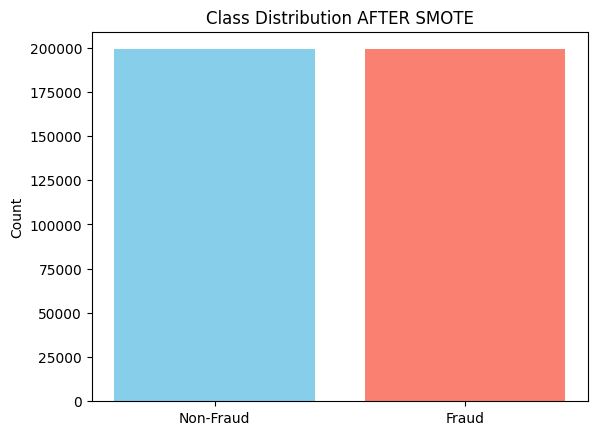

In [14]:
smote = SMOTE(sampling_strategy=1, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=['skyblue','salmon'])
plt.xticks([0,1], ['Non-Fraud', 'Fraud'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

In [15]:
print("\nClass distribution After Smote:")
print(y_train_sm.value_counts())  #Check class balance


Class distribution After Smote:
Class
0    199020
1    199020
Name: count, dtype: int64


Logistic Regression After SMOTE

In [16]:
model = LogisticRegression(solver='lbfgs', max_iter=200)
model.fit(X_train_sm, y_train_sm)

y_pred_sm = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_sm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_sm, target_names=['Not Fraud', 'Fraud']))

Accuracy: 0.9760425078707442

Classification Report:
               precision    recall  f1-score   support

   Not Fraud       1.00      0.98      0.99     85295
       Fraud       0.06      0.86      0.11       148

    accuracy                           0.98     85443
   macro avg       0.53      0.92      0.55     85443
weighted avg       1.00      0.98      0.99     85443



### XG Boost
- References: https://www.geeksforgeeks.org/machine-learning/xgboost/

XG Boost on Test
Model Accuracy: 0.9994382219725431

Classification Report
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     85295
       Fraud       0.95      0.71      0.81       148

    accuracy                           1.00     85443
   macro avg       0.98      0.85      0.91     85443
weighted avg       1.00      1.00      1.00     85443

XG Boost on Train
Model Accuracy: 0.999533516582733

Classification Report
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    199020
       Fraud       0.95      0.77      0.85       344

    accuracy                           1.00    199364
   macro avg       0.97      0.89      0.93    199364
weighted avg       1.00      1.00      1.00    199364



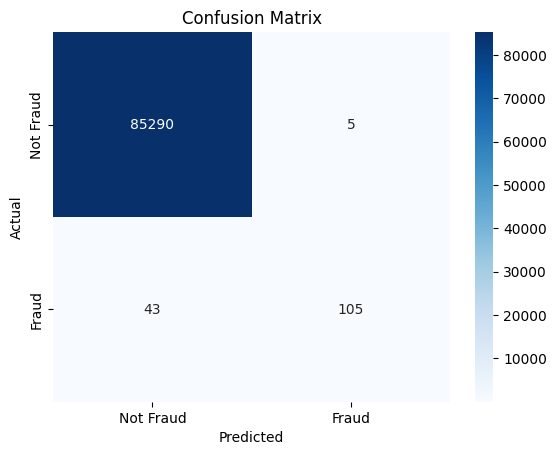

In [17]:
params = {
    'objective':'binary:logistic',
    'max_depth':4,
    'learning_rate':0.1,
    'n_estimators':100,
    'alpha':10
}

model = XGBClassifier(**params)
model.fit(X_train, y_train)

#on test
print('XG Boost on Test')
y_pred_xg_test = model.predict(X_test)

accuracy_xg_test = accuracy_score(y_test, y_pred_xg_test)
print("Model Accuracy:", accuracy_xg_test)

print("\nClassification Report")
print(classification_report(y_test, y_pred_xg_test, target_names=['Not Fraud', 'Fraud']))

#on train
print('XG Boost on Train')
y_pred_xg_train = model.predict(X_train)

accuracy_xg_train = accuracy_score(y_train, y_pred_xg_train)
print("Model Accuracy:", accuracy_xg_train)

print("\nClassification Report")
print(classification_report(y_train, y_pred_xg_train, target_names=['Not Fraud', 'Fraud']))

cm = confusion_matrix(y_test, y_pred_xg_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Decision Tree

Decision Tree on Train:
Accuracy: 0.9998

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    199020
       Fraud       0.99      0.92      0.95       344

    accuracy                           1.00    199364
   macro avg       0.99      0.96      0.98    199364
weighted avg       1.00      1.00      1.00    199364


Decision Tree on Test:
Accuracy: 0.9993

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     85295
       Fraud       0.86      0.71      0.78       148

    accuracy                           1.00     85443
   macro avg       0.93      0.85      0.89     85443
weighted avg       1.00      1.00      1.00     85443



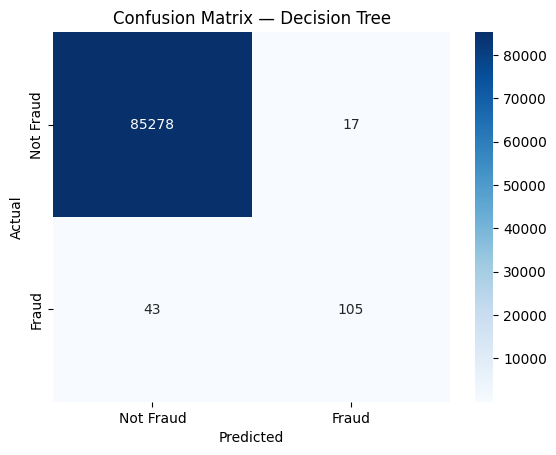

In [18]:
tree_params = None

if tree_params is None:
    tree_params = {
        'criterion': 'gini',
        'max_depth': 10,
        'random_state': 42
    }

model_dt = DecisionTreeClassifier(class_weight={0: 1, 1: 10}, **tree_params)

#Training
model_dt.fit(X_train, y_train)

#Predict + evaluate
y_train_pred = model_dt.predict(X_train)
print("Decision Tree on Train:")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}\n")
print(classification_report(y_train, y_train_pred, target_names=['Not Fraud', 'Fraud'], zero_division=0))

y_preds_dt = model_dt.predict(X_test)
print("\nDecision Tree on Test:")
print(f"Accuracy: {accuracy_score(y_test, y_preds_dt):.4f}\n")
print(classification_report(y_test, y_preds_dt, target_names=['Not Fraud', 'Fraud'], zero_division=0))

#Confusion Matrix
cm = confusion_matrix(y_test, y_preds_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Decision Tree')
plt.show()

### Random Forest
- https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/

Random Forest on test:
Accuracy: 0.9995

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     85295
       Fraud       0.95      0.76      0.84       148

    accuracy                           1.00     85443
   macro avg       0.97      0.88      0.92     85443
weighted avg       1.00      1.00      1.00     85443

Random Forest on train:
Accuracy: 0.9996

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    199020
       Fraud       0.96      0.81      0.88       344

    accuracy                           1.00    199364
   macro avg       0.98      0.90      0.94    199364
weighted avg       1.00      1.00      1.00    199364



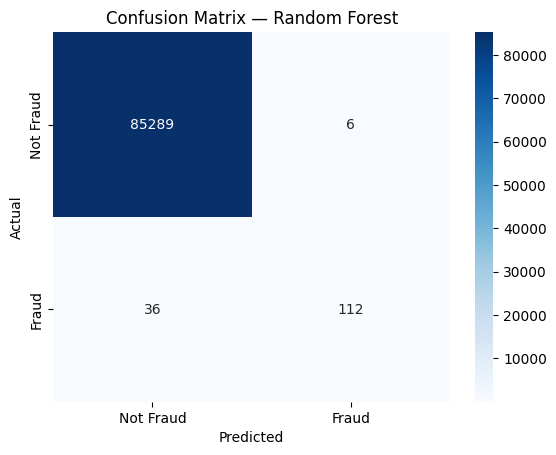

In [19]:
RF_classifier = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
RF_classifier.fit(X_train, y_train)
y_pred_rf = RF_classifier.predict(X_test)

#to fix the overfitting.
#max_depth=10 - stop after 10 questions, to avoid Memorization/reduce noise
#min_samples_leaf=5 - every leaf must contain at least 5 training samples.

#on test
print("Random Forest on test:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf, target_names=['Not Fraud', 'Fraud'], zero_division=0))

#on train
y_pred_rf_train = RF_classifier.predict(X_train)
print("Random Forest on train:")
print(f"Accuracy: {accuracy_score(y_train, y_pred_rf_train):.4f}\n")
print(classification_report(y_train, y_pred_rf_train, target_names=['Not Fraud', 'Fraud'], zero_division=0))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Random Forest')
plt.show()

### KNN

Accuracy: 0.9994

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     85295
       Fraud       0.91      0.70      0.79       148

    accuracy                           1.00     85443
   macro avg       0.96      0.85      0.90     85443
weighted avg       1.00      1.00      1.00     85443



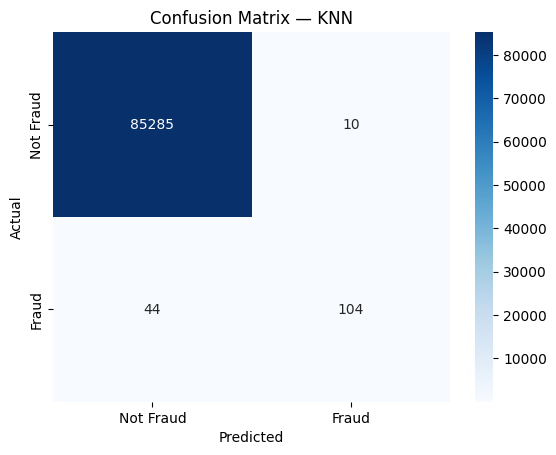

In [20]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)  # n_jobs=-1 uses all CPU cores
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}\n")
print(classification_report(y_test, y_pred_knn, target_names=['Not Fraud', 'Fraud'], zero_division=0))

cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — KNN')
plt.show()

Accuracy: 0.9781

              precision    recall  f1-score   support

   Not Fraud       1.00      0.98      0.99     85295
       Fraud       0.06      0.80      0.11       148

    accuracy                           0.98     85443
   macro avg       0.53      0.89      0.55     85443
weighted avg       1.00      0.98      0.99     85443



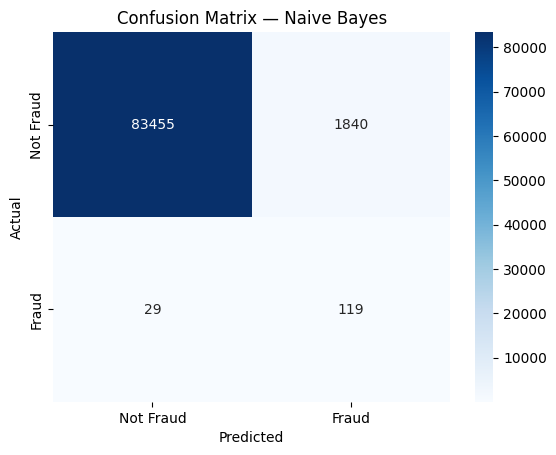

In [21]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}\n")
print(classification_report(y_test, y_pred_nb, target_names=['Not Fraud', 'Fraud'], zero_division=0))

cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Naive Bayes')
plt.show()